In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import ROOT
from scipy.optimize import curve_fit

In [ ]:
file = ROOT.TFile.Open("../DetectorSimulation/output/default.root")
tracks = file.Get("tracks")
tracks.Print()

In [4]:
num_tracks = tracks.GetEntries()

# First we cheat and skip the track finding step, and simply fit tracks

In [9]:
from helix_fitting import fit_helix, fit_helix_2, momentum_from_helix, DCA_from_helix, RMSE, helix

In [10]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))

In [13]:
B = 1.7

cutoff_momentum = 50_000 # 50 MeV

data = []

for i in range(num_tracks):
    tracks.GetEntry(i)
    if tracks.NumHits < 4:
        continue
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    d0, z0, phi0, fitted_pT, tanl = fit_helix_2(x, y, z, B)

    fitted_pZ = tanl * fitted_pT
    fitted_p = np.sqrt(fitted_pT ** 2 + fitted_pZ ** 2)

    pX, pY, pZ = tracks.MomentumX, tracks.MomentumY, tracks.MomentumZ
    p = np.sqrt(pX ** 2 + pY ** 2 + pZ ** 2)
    pT = np.sqrt(pX ** 2 + pY ** 2)
    eta = np.arctanh(pZ / p)

    delta_p = (fitted_p - p) / p
    delta_pT = (fitted_pT - pT) / pT 

    error = RMSE(x, y, z, x_c, y_c, z0, fitted_pZ, fitted_pT, R)

    if fitted_p > cutoff_momentum:
        continue

    data.append({
        "True Momentum (MeV/c)": round(p),
        "True Transverse Momentum (MeV/c)": pT,
        "True Z Momentum (MeV/c)": pZ,
        "Fitted Momentum (MeV/c)": fitted_p,
        "Fitted Transverse Momentum (MeV/c)": fitted_pT,
        "Fitted Z Momentum (MeV/c)": fitted_pZ,
        "Pseudorapidity": eta,
        "DCA (mm)": d0
    })

df2 = pd.DataFrame(data)
df2.head()

,True Momentum (MeV/c),True Transverse Momentum (MeV/c),True Z Momentum (MeV/c),Fitted Momentum (MeV/c),Fitted Transverse Momentum (MeV/c),Fitted Z Momentum (MeV/c),Pseudorapidity,DCA (mm)
0,3000,669.263364,-2924.395074,3019.356033,672.104575,-2943.600906,-2.180656,2637.569795
1,2000,287.029667,1979.296332,2051.999152,295.532258,2030.606117,2.629275,1159.282500
2,2000,220.811630,1987.773182,1962.521366,216.697412,1950.521044,2.893678,850.848922
3,700,686.655757,-136.028937,701.986266,688.576933,-136.552280,-0.196830,2702.161217
4,1000,995.594423,93.764303,997.390394,992.970065,93.797907,0.094041,3896.703854


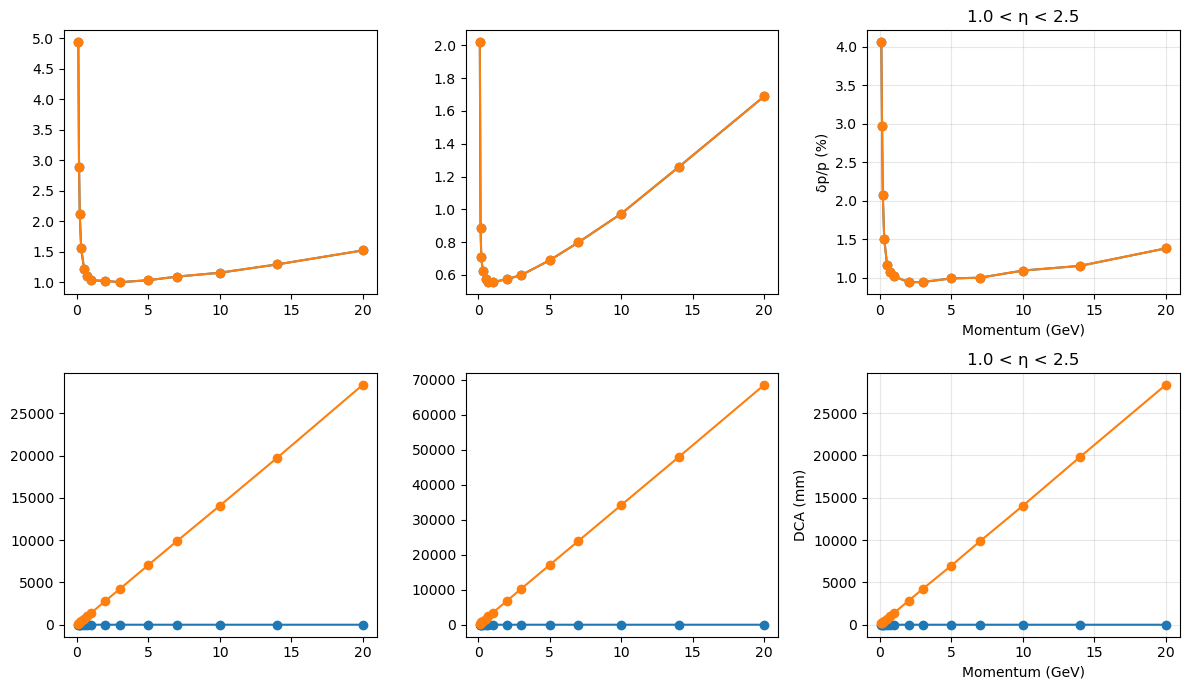

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for d in [df, df2]:
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = d[(d["Pseudorapidity"] >= eta_lo) &
                    (d["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())

        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2

            try:
                popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
                sigma_delta_pT.append(abs(popt[2]))  
            except:
                sigma_delta_pT.append(sigma_guess)   

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, marker="o")
        axes[1, i].plot(p_GeV, mean_DCA, marker="o")

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)


    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)


plt.tight_layout()
plt.show()

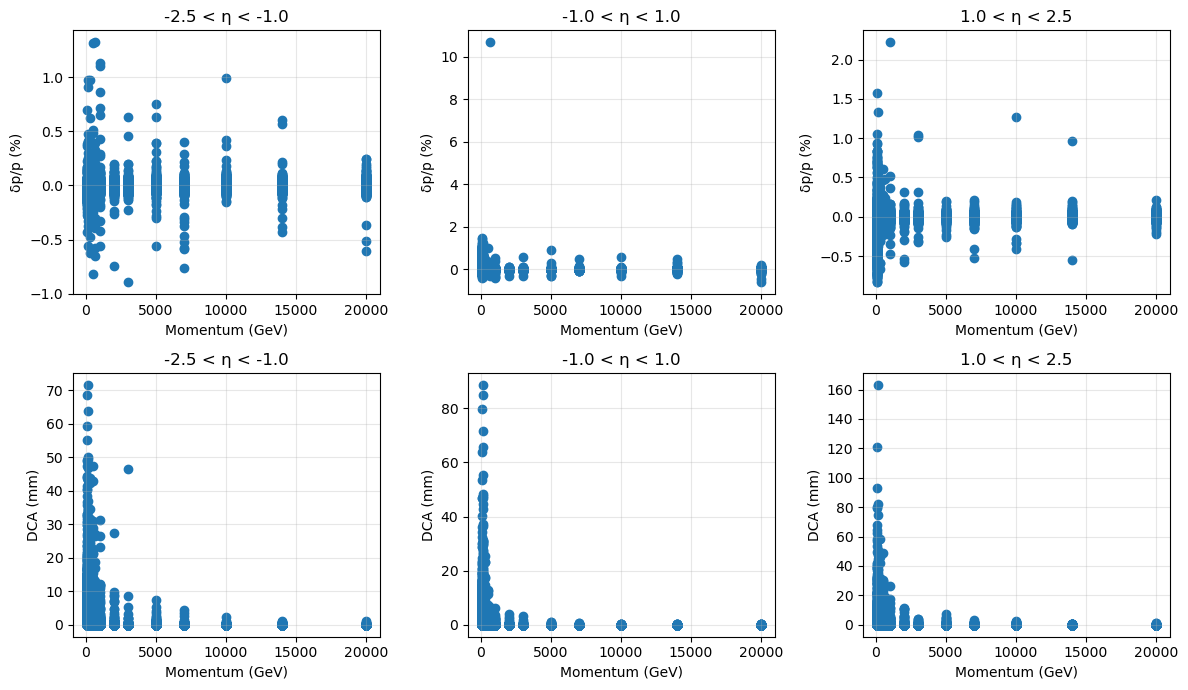

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())

    p_residual = (df_eta["Fitted Momentum (MeV/c)"] - df_eta["True Momentum (MeV/c)"]) / df_eta["True Momentum (MeV/c)"]

    axes[0, i].scatter(df_eta["True Momentum (MeV/c)"], p_residual)
    axes[1, i].scatter(df_eta["True Momentum (MeV/c)"], df_eta["DCA (mm)"])

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)

    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
plt.scatter(df["Momentum (MeV/c)"], df["DCA (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("DCA (mm)")
plt.title("DCA vs True Momentum")
plt.show()

KeyError: 'Momentum (MeV/c)'

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["z0 (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("z0 (mm)")
plt.title("z0 vs True Momentum")
plt.show()

In [ ]:
plt.scatter(df["Pseudorapidity"], df["Momentum Accuracy (%)"])
plt.xlabel("η")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Pseudorapidity")
plt.show()

In [ ]:
plt.scatter(df["Transverse Momentum Accuracy (%)"], df["Z Momentum Accuracy (%)"], alpha=0.01)
plt.ylim(0, 200)
plt.plot()

In [ ]:
plt.hist(df["Z Momentum Accuracy (%)"], bins=np.arange(0, 300, 0.5))
plt.xlim(-50, 250)
plt.show()

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["Momentum Accuracy (%)"], alpha=0.01)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Momentum")
plt.ylim(0, 200)
plt.xlim(0, 2500)
plt.show()

In [ ]:
plt.scatter(df["RMSE"], df["Momentum Accuracy (%)"], alpha=0.05)
plt.xlabel("RMSE")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs RMSE")
plt.ylim(0, 500)
plt.xlim(-50, 500)
plt.show()

In [ ]:
plt.scatter(df["RMSE"], df["DCA (mm)"], alpha=0.1)
plt.xlabel("RMSE")
plt.ylabel("DCA (mm)")
plt.title("DCA Accuracy vs RMSE")
plt.ylim(0, 20)
plt.xlim(-10, 200)
plt.show()

In [ ]:
plt.scatter( df["Momentum (MeV/c)"], df["RMSE"], alpha=0.1)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("RMSE")
plt.title("Momentum vs RMSE")
plt.xlim(1000, 20000)
plt.ylim(-1, 3)
plt.show()

In [ ]:
df.sort_values(by="Momentum Accuracy (%)", ascending=False).head(100)

In [ ]:
df.sort_values(by="RMSE", ascending=False).head()

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

track = track_hits[632]
x, y, z = track

ax.scatter(x, y, z, c="r")

x_c, y_c, R, tanl, z0, phi = fit_helix(x, y, z)

fitted_pT, fitted_pZ = momentum_from_helix(R, tanl, B)
fitted_DCA = DCA_from_helix(x_c, y_c, R)

phi0 = phi[0]
sample_phi = np.linspace(phi[0], phi[-1], 1000)
x_fit, y_fit, z_fit = helix(x_c, y_c, z0, fitted_pZ, fitted_pT, R, sample_phi)
ax.plot(x_fit, y_fit, z_fit)

In [ ]:
plt.scatter(x, y)
plt.plot(x_fit, y_fit)

In [ ]:
plt.scatter(phi, z)
plt.plot(sample_phi, z_fit)

In [ ]:
plt.scatter(x, z)
plt.plot(x_fit, z_fit)